Nama : Mika Khairan Djubikit
NIM  : F1D02310075

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import cv2


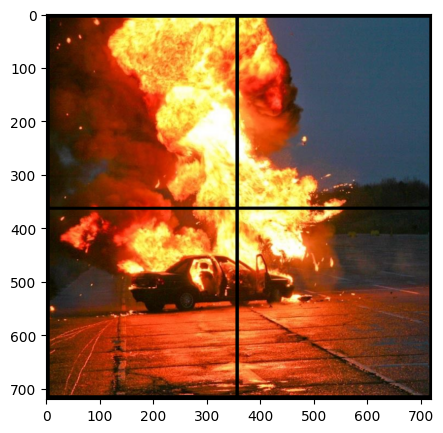

In [18]:
citraA = plt.imread("Assets/Meledak.png")

fig = plt.subplots( figsize=(10, 5))
plt.imshow(citraA)
plt.show()


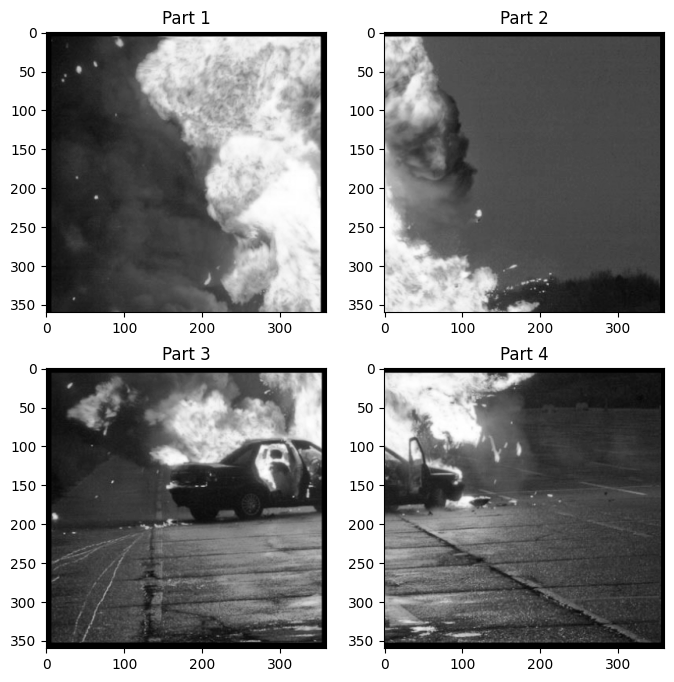

In [ ]:
img_ledakan = cv2.imread('Assets/Meledak.png', cv2.IMREAD_GRAYSCALE)

# 2. PROSES SLICING (Memecah menjadi 4 bagian)
h, w = img_ledakan.shape
mid_h, mid_w = h // 2, w // 2

part1 = img_ledakan[:mid_h, :mid_w]
part2 = img_ledakan[:mid_h, mid_w:]
part3 = img_ledakan[mid_h:, :mid_w]
part4 = img_ledakan[mid_h:, mid_w:]

# Tampilkan dulu keempat potongan untuk menganalisis posisinya
fig, ax = plt.subplots(2, 2, figsize=(8, 8))
ax[0, 0].imshow(part1, cmap='gray'); ax[0, 0].set_title("Part 1")
ax[0, 1].imshow(part2, cmap='gray'); ax[0, 1].set_title("Part 2")
ax[1, 0].imshow(part3, cmap='gray'); ax[1, 0].set_title("Part 3")
ax[1, 1].imshow(part4, cmap='gray'); ax[1, 1].set_title("Part 4")

plt.show()

Text(0.5, 1.0, 'Part4')

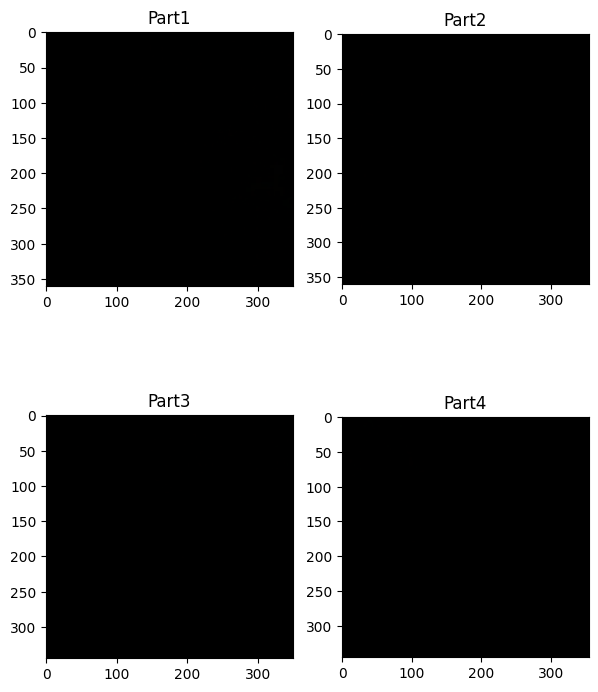

In [ ]:
def fungsi_slicing(gambar, a, b, mode='H'):
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

potong1 = fungsi_slicing(citraA, 0, 360)
gambar_1 = fungsi_slicing(potong1, 0, 350, 'V')
gambar_2 = fungsi_slicing(potong1, 360, 715, 'V')

potong2 = fungsi_slicing(citraA, 370, 715)
gambar_3 = fungsi_slicing(potong2, 0, 350, 'V')
gambar_4 = fungsi_slicing(potong2, 360, 715, 'V')

plt.figure(figsize=(7, 9))

plt.subplot(2, 2, 1)
plt.imshow(gambar_1)
plt.title("Part1")

plt.subplot(2, 2, 2)
plt.imshow(gambar_2)
plt.title("Part2")

plt.subplot(2, 2, 3)
plt.imshow(gambar_3)
plt.title("Part3")

plt.subplot(2, 2, 4)
plt.imshow(gambar_4)
plt.title("Part4")

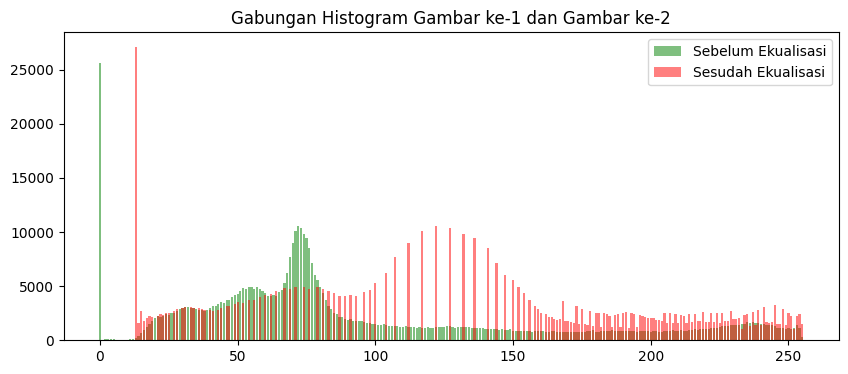

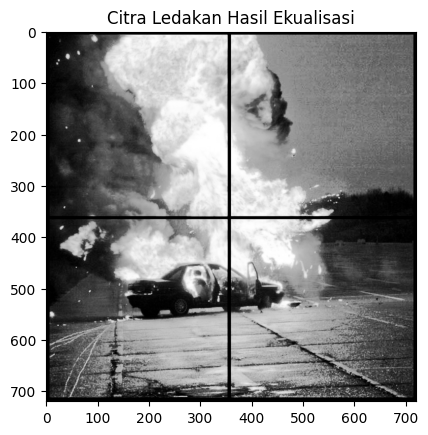

In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. MEMBACA CITRA LEDAKAN
# Ganti 'ledakan.jpg' dengan nama file asli Anda
img_ledakan = cv2.imread('Assets/Meledak.png', cv2.IMREAD_GRAYSCALE)

# 2. PROSES SLICING (Memecah menjadi 4 bagian)
h, w = img_ledakan.shape
mid_h, mid_w = h // 2, w // 2

part1 = img_ledakan[:mid_h, :mid_w]
part2 = img_ledakan[:mid_h, mid_w:]
part3 = img_ledakan[mid_h:, :mid_w]
part4 = img_ledakan[mid_h:, mid_w:]

# 3. PENGGABUNGAN KEMBALI (Menyusun citra utuh)
# Membuat kanvas kosong menggunakan np.zeros
ledakan_utuh = np.zeros((h, w), dtype=np.uint8)
ledakan_utuh[:mid_h, :mid_w] = part1
ledakan_utuh[:mid_h, mid_w:] = part2
ledakan_utuh[mid_h:, :mid_w] = part3
ledakan_utuh[mid_h:, mid_w:] = part4

# 4. EKUALISASI HISTOGRAM MANUAL
# a. Hitung Histogram
hist_ledakan = np.zeros(256)
for i in range(h):
    for j in range(w):
        hist_ledakan[ledakan_utuh[i, j]] += 1

# b. Hitung CDF (Cumulative Distribution Function)
cdf_ledakan = np.zeros(256)
cdf_ledakan[0] = hist_ledakan[0]
for i in range(1, 256):
    cdf_ledakan[i] = cdf_ledakan[i-1] + hist_ledakan[i]

# c. Hitung Nilai Intensitas Baru (Transformasi)
total_pixels = h * w
map_ledakan = np.round((cdf_ledakan / total_pixels) * 255).astype(np.uint8)

# d. Terapkan Pemetaan ke Citra Baru
ledakan_eq = np.zeros((h, w), dtype=np.uint8)
for i in range(h):
    for j in range(w):
        ledakan_eq[i, j] = map_ledakan[ledakan_utuh[i, j]]

# Menghitung histogram setelah ekualisasi untuk plot
hist_eq = np.zeros(256)
for i in range(h):
    for j in range(w):
        hist_eq[ledakan_eq[i, j]] += 1

# 5. MENAMPILKAN HASIL TAHAP 1
plt.figure(figsize=(10, 4))
plt.bar(range(256), hist_ledakan, color='green', alpha=0.5, label='Sebelum Ekualisasi')
plt.bar(range(256), hist_eq, color='red', alpha=0.5, label='Sesudah Ekualisasi')
plt.title("Gabungan Histogram Gambar ke-1 dan Gambar ke-2")
plt.legend()
plt.show()

plt.imshow(ledakan_eq, cmap='gray')
plt.title("Citra Ledakan Hasil Ekualisasi")
plt.show()